# Reproduce the Paper's Main Figure

Rebuilds the paper's main figure, its zoomed appendix version, and the appendix $R^2$ table from the tracked `loss_history.csv` files -- no retraining needed. Uses the same code as `evaluation/results_3d_shared_test10000.sh`.

**Prerequisites**
- Kernel: `stream_transfer_learning`
- LaTeX: next cell loads `texlive/2024` automatically

**Note:** `.npz` files are also tracked (for recomputing bootstrap stats via `src/compute_bootstrap_shared_test.py`), but not needed for this figure.

In [1]:
# Load texlive/2024 onto PATH
import os
import shutil
import subprocess


def ensure_module_on_path(module_name):
    result = subprocess.run(
        ["bash", "-c", f"module load {module_name} >/dev/null 2>&1; echo $PATH"],
        capture_output=True, text=True, env=os.environ,
    )
    new_path = result.stdout.strip()
    if not new_path or new_path == os.environ.get("PATH", ""):
        raise RuntimeError(f"`module load {module_name}` did not change PATH (stderr: {result.stderr!r})")
    os.environ["PATH"] = new_path


ensure_module_on_path("texlive/2024")

for exe in ("latex", "dvipng", "kpsewhich"):
    assert shutil.which(exe), f"{exe} still not found on PATH after `module load texlive/2024`"
print("LaTeX toolchain ready:", shutil.which("latex"))

LaTeX toolchain ready: /global/common/software/nersc9/texlive/2024/bin/x86_64-linux/latex


In [2]:
import sys
sys.path.insert(0, "../src")

from build_results_table import build_table, compute_test_label_variance_from_labels

In [3]:
# Model list (matches results_3d_shared_test10000.sh, METRIC=r2)
dataset_sizes = [300, 1000, 10000]

model_list = []
for ds in dataset_sizes:
    model_list += [
        ("3d_x_y_z", ds, "omnicosmos_camels_finetune_1x4", "OmniCosmos_CAMELS"),
        ("3d_x_y_z", ds, "omnicosmos_quijote_finetune_1x4", "OmniCosmos_Quijote"),
        ("3d_x_y_z", ds, "baseline_256", "DeepSets_256"),
        ("3d_x_y_z", ds, "eigenvalue_regression", "eigenvalue_regression"),
        ("3d_x_y_z", ds, "omnilearned_scratch_1x4", "OmniLearned_Scratch"),
        ("3d_x_y_z", ds, "omnilearned_finetune_1x4", "OmniLearned_Finetune"),
        ("3d_x_y_z", ds, "omnilearned_proxy_cube_finetune_1x4", "proxy_cube"),
        ("3d_x_y_z", ds, "omnilearned_proxy_bounded_ball_finetune_1x4", "proxy_bounded_ball"),
        ("3d_x_y_z", ds, "omnilearned_proxy_gaussian_ball_finetune_1x4", "proxy_gaussian_ball"),
        ("3d_x_y_z", ds, "omnilearned_proxy_gaussian_ellipsoid_sigmax_finetune_1x4", "proxy_gaussian_ellipsoid_sigmax"),
        ("3d_x_y_z", ds, "omnilearned_proxy_bounded_ellipsoid_a_finetune_1x4", "proxy_bounded_ellipsoid_a"),
        ("3d_x_y_z", ds, "omnilearned_proxy_box_a_finetune_1x4", "proxy_box_a"),
        ("3d_x_y_z", ds, "omnilearned_proxy_eigen_lambda1_finetune_1x4", "proxy_stream_eigenvalues_lambda1"),
    ]

len(model_list)

39

In [4]:
# R^2 reference variance (from sidecar labels)
r2_reference_var = compute_test_label_variance_from_labels("prog_mass_labels_10000_test.npy")
print(f"R^2 reference Var(y_test) = {r2_reference_var:.6f}")

R^2 reference Var(y_test) = 0.265821


In [5]:
# Overwrites the same tracked figure/table files
scatter_path = "results_3d_shared_test10000_scatter_r2_bootstrap_nested.png"
latex_path = "results_3d_shared_test10000.tex"

# Shared by both passes -- only the y-axis crop differs.
common = dict(
    repo_root="..",
    epochs=50,
    indices=[0, 1, 2],
    test_csv_name="shared_test10000_bootstrap/loss_history.csv",
    metric="r2",
    r2_reference_var=r2_reference_var,
    error_column="Test_Loss_Bootstrap_Std",
    combine_errors=True,
)

df, table_df, best_mask = build_table(
    model_list,
    save_scatter=scatter_path,
    save_latex=latex_path,
    return_table_frames=True,
    **common,
)
df

Saved LaTeX table -> results_3d_shared_test10000.tex
Saved scatter plot -> results_3d_shared_test10000_scatter_r2_bootstrap_nested.png
Saved scatter plot -> results_3d_shared_test10000_scatter_r2_bootstrap_nested.pdf


,Model,n_indices,Best Val MSE,Test MSE (at best val)
0,3d_x_y_z_10000+proxy_gaussian_ellipsoid_sigmax,3,0.0037 ± 0.0004 (stat 0.0003),0.0037 ± 0.0004 (stat 0.0003)
1,3d_x_y_z_10000+proxy_bounded_ellipsoid_a,3,0.0039 ± 0.0003 (stat 0.0003),0.0039 ± 0.0003 (stat 0.0003)
2,3d_x_y_z_10000+proxy_stream_eigenvalues_lambda1,3,0.0042 ± 0.0008 (stat 0.0003),0.0042 ± 0.0008 (stat 0.0003)
3,3d_x_y_z_10000+OmniCosmos_Quijote,3,0.0044 ± 0.0004 (stat 0.0003),0.0044 ± 0.0004 (stat 0.0003)
4,3d_x_y_z_10000+proxy_cube,3,0.0044 ± 0.0004 (stat 0.0003),0.0044 ± 0.0004 (stat 0.0003)
5,3d_x_y_z_10000+OmniLearned_Finetune,3,0.0046 ± 0.0004 (stat 0.0003),0.0046 ± 0.0004 (stat 0.0003)
6,3d_x_y_z_10000+proxy_gaussian_ball,3,0.0046 ± 0.0003 (stat 0.0003),0.0046 ± 0.0003 (stat 0.0003)
7,3d_x_y_z_10000+proxy_bounded_ball,3,0.0046 ± 0.0003 (stat 0.0003),0.0046 ± 0.0003 (stat 0.0003)
8,3d_x_y_z_10000+OmniLearned_Scratch,3,0.0049 ± 0.0004 (stat 0.0003),0.0049 ± 0.0004 (stat 0.0003)
9,3d_x_y_z_10000+proxy_box_a,3,0.0050 ± 0.0004 (stat 0.0003),0.0050 ± 0.0004 (stat 0.0003)


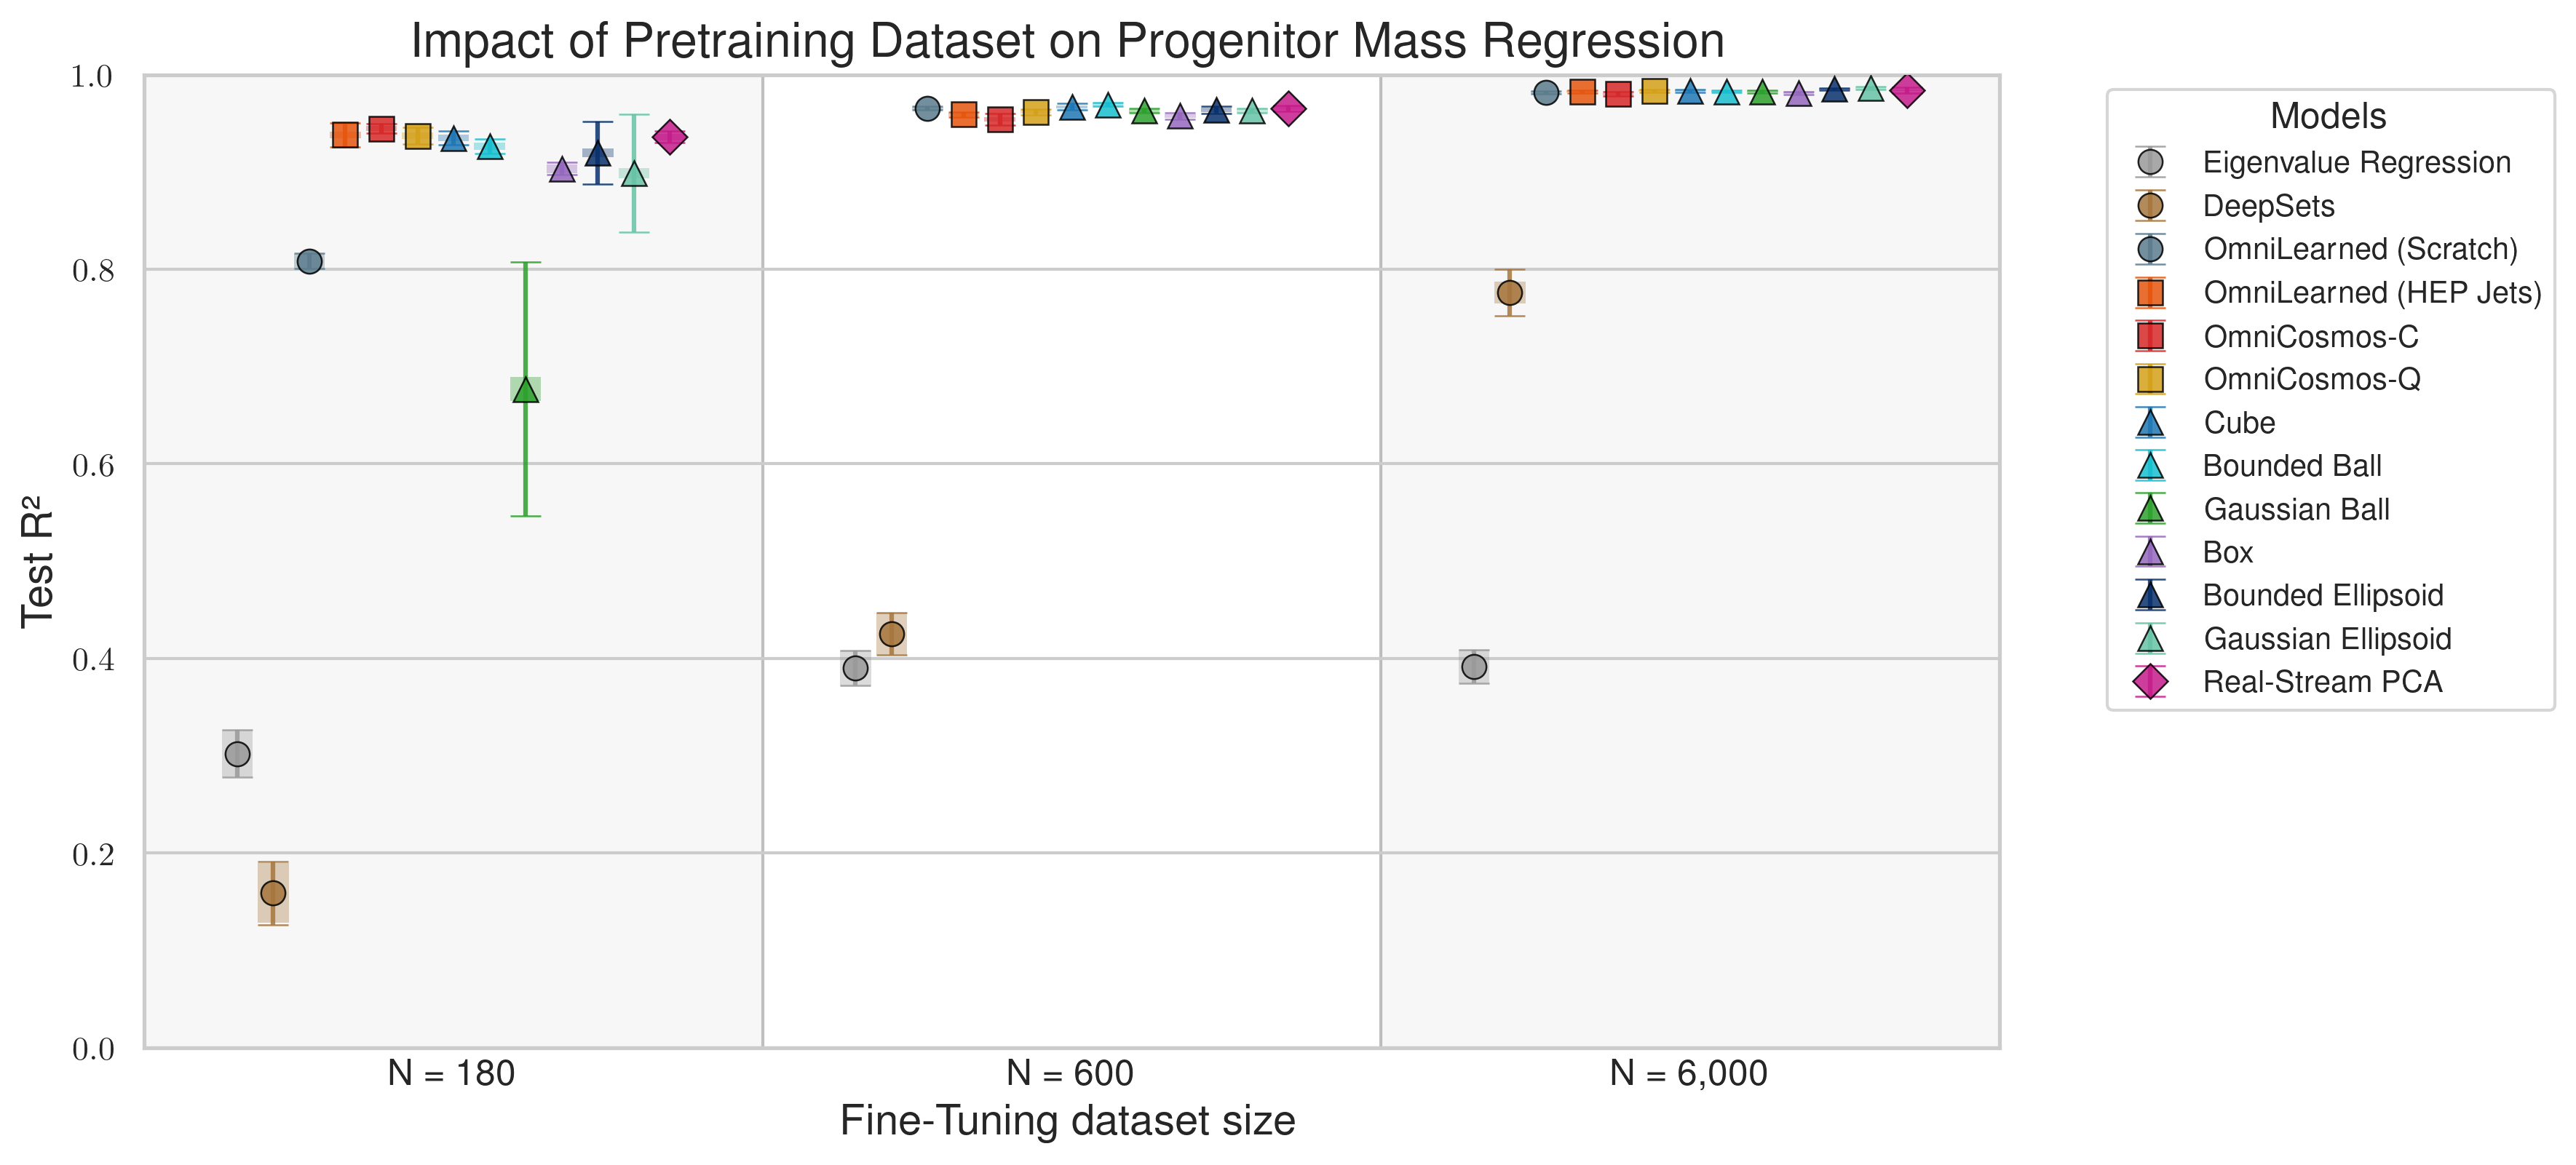

In [6]:
from IPython.display import Image
Image(filename=scatter_path)

## Appendix figure: zoomed view

Same numbers, $y$-axis cropped to $[0.8, 1.0]$ so the spread among the pre-trained
models is readable. DeepSets and Eigenvalue Regression fall below the axis at every
dataset size (they stay in the legend); Gaussian Ball is off-axis at 180.

Saved scatter plot -> results_3d_shared_test10000_scatter_r2_ymin08_bootstrap_nested.png
Saved scatter plot -> results_3d_shared_test10000_scatter_r2_ymin08_bootstrap_nested.pdf


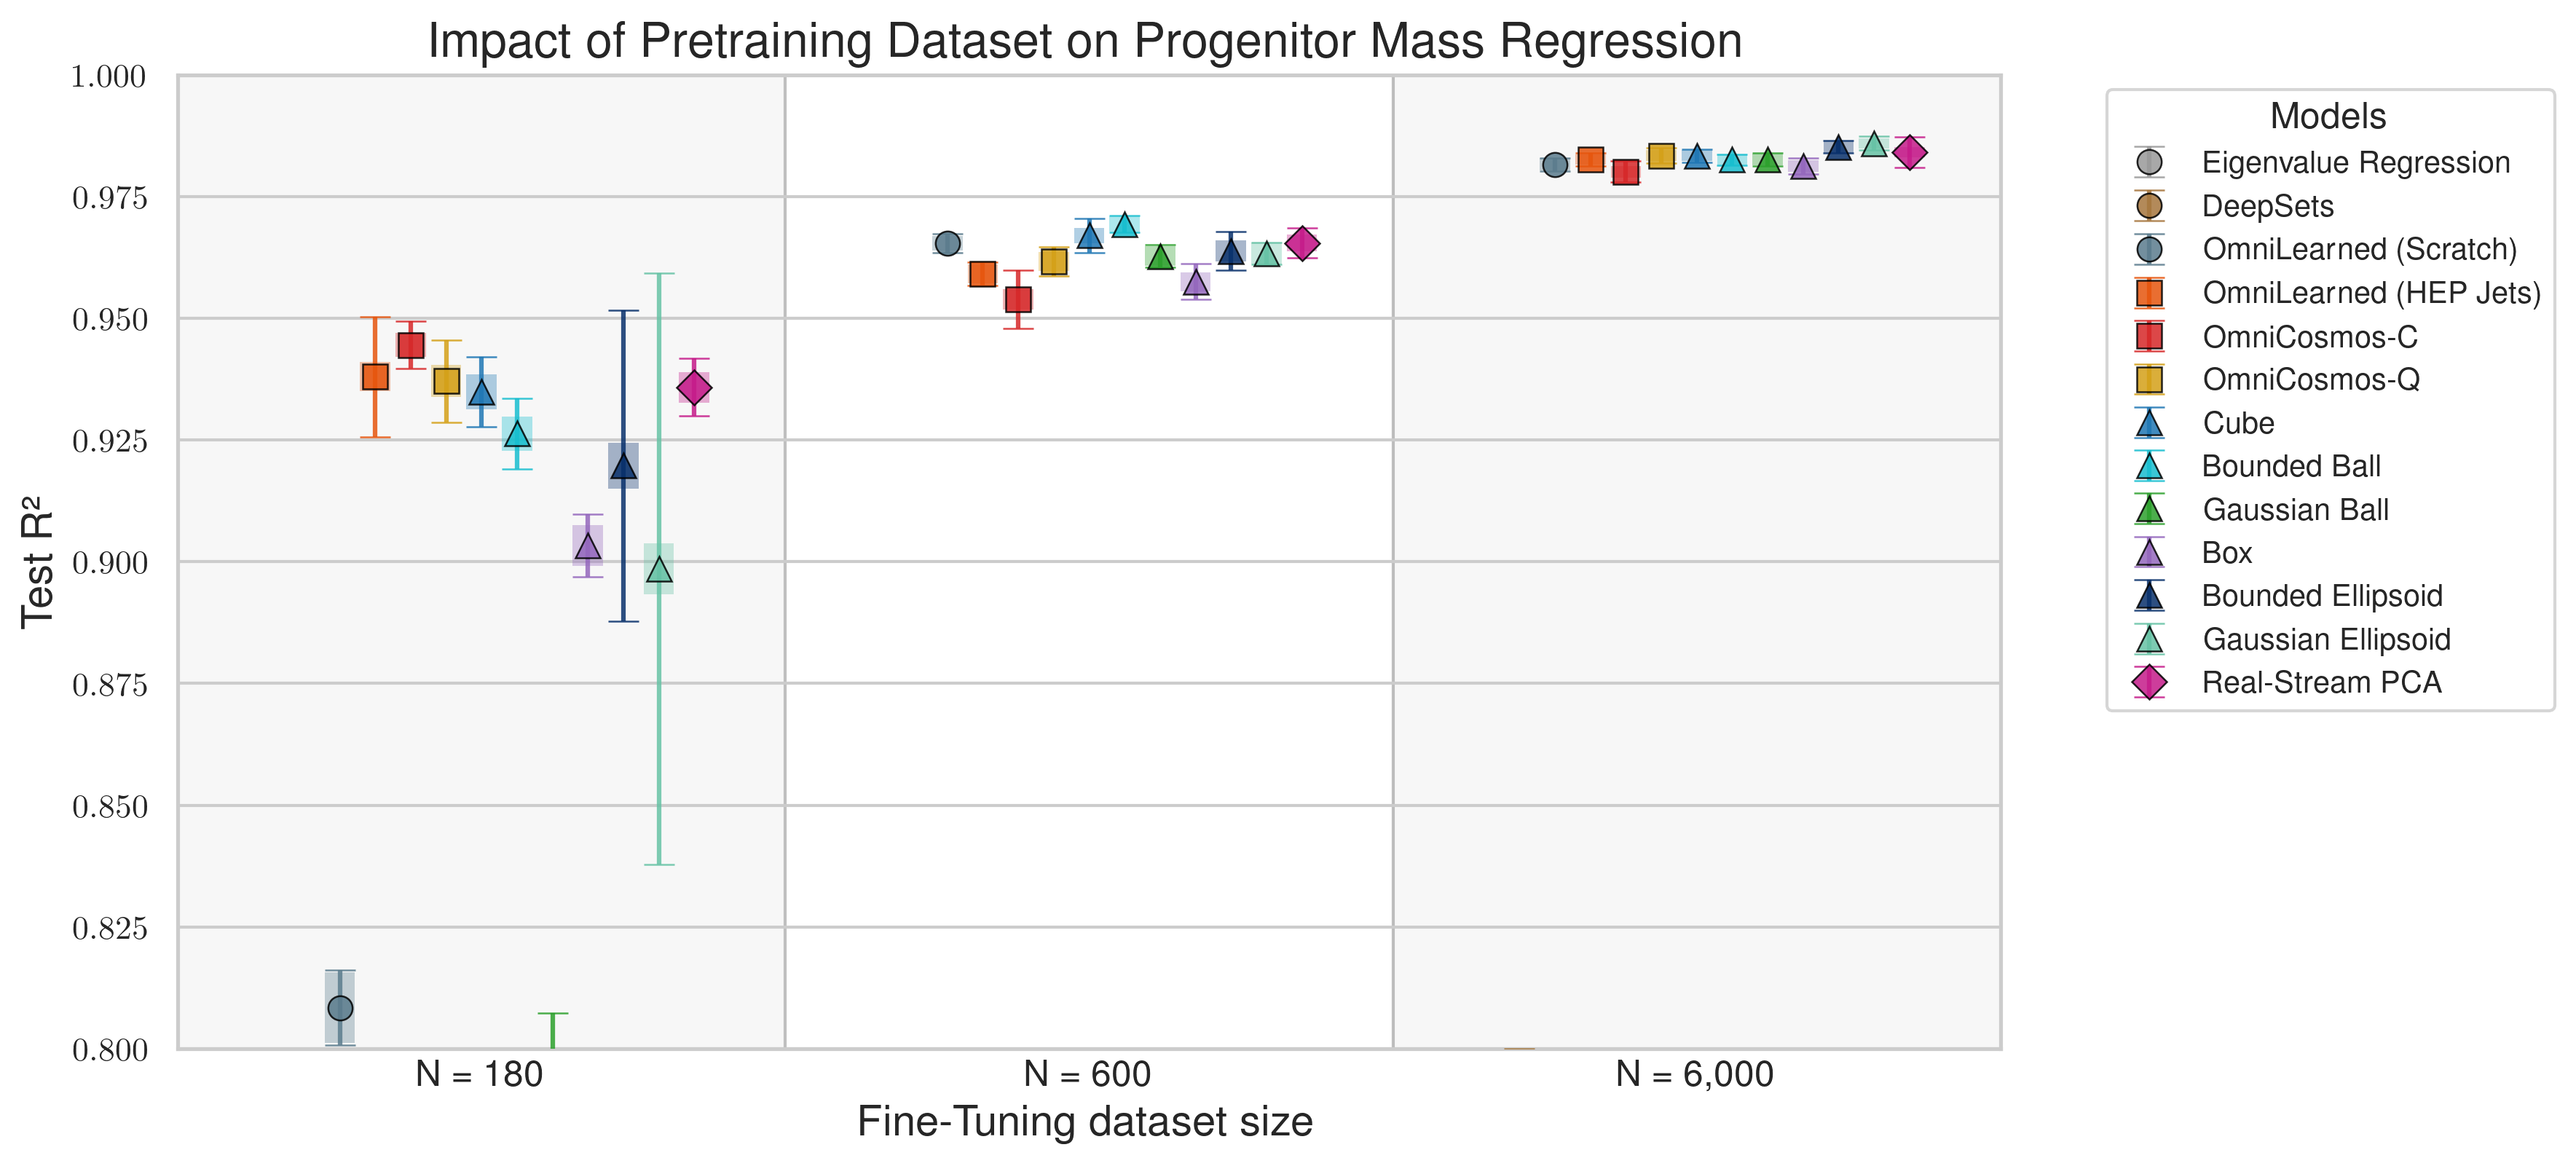

In [7]:
# The "_ymin08" suffix keeps this from overwriting the main figure above.
zoom_path = "results_3d_shared_test10000_scatter_r2_ymin08_bootstrap_nested.png"

# No save_latex here -- the table doesn't depend on the y-axis crop, so it is
# written once, by the cell above (same as LATEX_TABLE=false for the shell script).
build_table(model_list, save_scatter=zoom_path, r2_ymin=0.8, **common)

Image(filename=zoom_path)

## Appendix table

Same numbers as the figure, as $R^2 \pm$ total uncertainty (bootstrap-only in parentheses).
Bold = best mean $R^2$ at that dataset size.

In [8]:
import numpy as np

table_df.style.apply(
    lambda _: np.where(best_mask, "font-weight: bold", ""), axis=None
)

,180,600,"6,000"
Model,,,
Eigenvalue Regression,0.302 ± 0.024 (0.024),0.390 ± 0.018 (0.018),0.392 ± 0.017 (0.017)
DeepSets,0.159 ± 0.032 (0.031),0.425 ± 0.022 (0.022),0.776 ± 0.024 (0.011)
OmniLearned (Scratch),0.808 ± 0.008 (0.007),0.965 ± 0.002 (0.002),0.982 ± 0.001 (0.001)
OmniLearned (HEP Jets),0.938 ± 0.012 (0.003),0.959 ± 0.002 (0.002),0.983 ± 0.001 (0.001)
OmniCosmos-C,0.944 ± 0.005 (0.003),0.954 ± 0.006 (0.002),0.980 ± 0.002 (0.001)
OmniCosmos-Q,0.937 ± 0.008 (0.003),0.962 ± 0.003 (0.002),0.983 ± 0.002 (0.001)
Cube,0.935 ± 0.007 (0.004),0.967 ± 0.003 (0.002),0.983 ± 0.001 (0.001)
Bounded Ball,0.926 ± 0.007 (0.004),0.969 ± 0.002 (0.002),0.983 ± 0.001 (0.001)
Gaussian Ball,0.677 ± 0.130 (0.012),0.963 ± 0.002 (0.002),0.983 ± 0.001 (0.001)


The same table as a bare LaTeX `tabular`, written to `results_3d_shared_test10000.tex`:

In [9]:
print(open(latex_path).read())

{\setlength{\tabcolsep}{4pt}\small
\begin{tabular}{lccc}
\toprule
Model & 180 & 600 & 6,000 \\
\midrule
Eigenvalue Regression & $0.302 \pm 0.024\,(0.024)$ & $0.390 \pm 0.018\,(0.018)$ & $0.392 \pm 0.017\,(0.017)$ \\
DeepSets & $0.159 \pm 0.032\,(0.031)$ & $0.425 \pm 0.022\,(0.022)$ & $0.776 \pm 0.024\,(0.011)$ \\
OmniLearned (Scratch) & $0.808 \pm 0.008\,(0.007)$ & $0.965 \pm 0.002\,(0.002)$ & $0.982 \pm 0.001\,(0.001)$ \\
\midrule
OmniLearned (HEP Jets) & $0.938 \pm 0.012\,(0.003)$ & $0.959 \pm 0.002\,(0.002)$ & $0.983 \pm 0.001\,(0.001)$ \\
OmniCosmos-C & $\mathbf{0.944 \pm 0.005\,(0.003)}$ & $0.954 \pm 0.006\,(0.002)$ & $0.980 \pm 0.002\,(0.001)$ \\
OmniCosmos-Q & $0.937 \pm 0.008\,(0.003)$ & $0.962 \pm 0.003\,(0.002)$ & $0.983 \pm 0.002\,(0.001)$ \\
\midrule
Cube & $0.935 \pm 0.007\,(0.004)$ & $0.967 \pm 0.003\,(0.002)$ & $0.983 \pm 0.001\,(0.001)$ \\
Bounded Ball & $0.926 \pm 0.007\,(0.004)$ & $\mathbf{0.969 \pm 0.002\,(0.002)}$ & $0.983 \pm 0.001\,(0.001)$ \\
Gaussian Ball & $0.6